# DATA 266 Lab 1 — Task 1
## A GPT-style LLM built from scratch on TinyStories (character level)

**Shriram Dundigalla** · Lab Pair 33

This notebook walks through the run that produced every number in
`task1_llm/shriram_dundigalla/metrics_report.csv`.

**How to read it.** The 12-epoch training loop was executed by `src/train.py` as a
single 102-minute job; section 3 prints that run's **unedited raw log** and rebuilds its
curves. Everything else in this notebook — the preprocessing, the model construction,
the causal-mask verification, the metric recomputation from the checkpoint, and the full
generation sweep — executes live here against the committed checkpoint. Section 3 also
contains the one-line call that reproduces the training run from scratch, guarded by a
flag so re-running this notebook does not silently spend another 102 minutes.

No prebuilt Transformer or attention module is used anywhere: no `nn.Transformer`,
no `nn.TransformerEncoderLayer`, no `nn.MultiheadAttention`, no
`F.scaled_dot_product_attention`. Section 2 prints the attention source so this is
checkable rather than asserted.

---
## Part 0 — Setup

The device order is CUDA, then Apple MPS, then CPU, so this notebook runs unchanged on the GPU lab machines and on my laptop. Every path is derived from the repo root, so there are no personal paths in the committed file.

In [1]:
import inspect, json, sys, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt

# Resolve the repo root from the notebook location, then put src/ on the path.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "task1_llm").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "task1_llm/shriram_dundigalla/src"
sys.path.insert(0, str(SRC))

import data as data_mod
import metrics as metrics_mod
import model as model_mod
from model import GPT, GPTConfig
from train import pick_device, device_name, set_seed, lr_at

CFG = yaml.safe_load((SRC / "config.yaml").read_text("utf-8"))
device = pick_device()
set_seed(CFG["seed"])

# Only the folder name. Printing the absolute path would put a personal path into a
# committed file, which section 5 of the handout forbids -- and it is this notebook
# that claims, two cells up, that there are none.
print("repo root :", REPO_ROOT.name + "/  (resolved from this notebook's location)")
print("torch     :", torch.__version__)
print("device    :", device, "|", device_name(device))
print("seed      :", CFG["seed"])

repo root : Lab1/  (resolved from this notebook's location)
torch     : 2.14.0
device    : mps | Apple MPS (arm)
seed      : 9015


In [2]:
# The full run configuration, for the record.
print(yaml.safe_dump(CFG, sort_keys=False).rstrip())

run_name: gpt_char_tinystories_v1
seed: 9015
data:
  stories_jsonl: task1_llm/data/tinystories_train_first20000.jsonl
  block_size: 128
  n_train_windows: 100000
  n_val_windows: 10000
  val_story_frac: 0.1
model:
  n_layer: 6
  n_head: 8
  d_model: 256
  d_ff_mult: 4
  dropout: 0.1
train:
  epochs: 12
  batch_size: 128
  lr: 0.0003
  min_lr_frac: 0.1
  warmup_frac: 0.03
  weight_decay: 0.1
  betas:
  - 0.9
  - 0.95
  grad_clip: 1.0
  log_every: 50
  num_workers: 0
eval:
  train_eval_batches: null
generate:
  prompt: Once upon a time
  max_new_tokens: 400
  temperatures:
  - 0.0
  - 0.5
  - 0.8
  - 1.0
  - 1.2
  top_k: null
  prompts:
  - Once upon a time
  - The little girl found a
  - Tom was very sad because
  - '"Hello," said the'
  - The two cats were
  n_samples: 3
  decoding_variants:
  - name: plain
    top_k: null
    top_p: null
    repetition_penalty: 1.0
  - name: top_k_40
    top_k: 40
    top_p: null
    repetition_penalty: 1.0
  - name: top_p_0.9
    top_k: null
    top_

---
# Part 1 — Data preprocessing

## 1.1 The corpus

The shared raw data is the first 20,000 rows of the TinyStories training split, streamed
rather than downloading the full ~2 GB corpus (`scripts/fetch_data.py`).

In [3]:
stories = data_mod.load_stories(REPO_ROOT / CFG["data"]["stories_jsonl"])
lengths = np.array([len(s) for s in stories])

print(f"stories            : {len(stories):,}")
print(f"characters total   : {lengths.sum():,}")
print(f"characters / story : mean {lengths.mean():.0f}, median {np.median(lengths):.0f}, "
      f"min {lengths.min()}, max {lengths.max()}")
print()
print("--- first story, verbatim ---")
print(stories[0])

stories            : 20,000
characters total   : 17,890,906
characters / story : mean 895, median 785, min 205, max 4540

--- first story, verbatim ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


## 1.2 Splitting by story, not by character offset

Section 1.1.4 asks for a 100K / 10K train/validation split. Two things about it are mine
to decide, and both matter.

**What the counts mean.** The brief never says 100K *of what*. I read it as
**sequences**, because step 1.1.2 is what creates the sequence dataset that step 1.1.4
then splits. The windows are **non-overlapping**, so 100,000 training sequences of 128
characters is one genuine pass over 12.8M characters. A stride-1 sliding window — what I
used for HW4 — would have made "100K sequences" mean 100,000 near-duplicate views of
about 100K characters, so 12 epochs would really be ~1,200 passes over a tiny corpus.

**Where the cut goes.** The split is over **whole stories**. Concatenating everything
into one character stream and cutting at a single offset leaks the text either side of
the cut into both halves' windows. Splitting by story means no validation character
appears in any training window.

In [4]:
bundle = data_mod.build(
    REPO_ROOT / CFG["data"]["stories_jsonl"],
    block_size=CFG["data"]["block_size"],
    n_train_windows=CFG["data"]["n_train_windows"],
    n_val_windows=CFG["data"]["n_val_windows"],
    val_story_frac=CFG["data"]["val_story_frac"],
    seed=CFG["seed"],
)
tok = bundle.tokenizer

print(f"stories     train {bundle.n_train_stories:,}  val {bundle.n_val_stories:,}")
print(f"characters  train {len(bundle.train_text):,}  val {len(bundle.val_text):,}")
print(f"windows     train {len(bundle.train_ds):,}  val {len(bundle.val_ds):,}")
print(f"characters consumed by windows: train "
      f"{len(bundle.train_ds) * CFG['data']['block_size']:,}")

stories     train 18,000  val 2,000
characters  train 16,172,268  val 1,758,634
windows     train 100,000  val 10,000
characters consumed by windows: train 12,800,000


## 1.3 Character-level tokenisation

`char_to_idx` and `idx_to_char` are my own dictionaries, built by sorting the character set so IDs are identical on every run. The vocabulary is built from the **training text only** — a character that appears only in validation is one the model genuinely has never seen, and folding it into the vocabulary would hide that instead of measuring it. Index 0 is a reserved `<unk>`.

In [5]:
print(f"vocab size : {tok.vocab_size}")
print()
printable = "".join(tok.idx_to_char[i] for i in range(tok.vocab_size))
print("vocabulary :", repr(printable))
print()
sample = "Once upon a time"
ids = tok.encode(sample)
print("encode :", sample, "->", ids)
print("decode :", ids, "->", repr(tok.decode(ids)))
print("round-trip exact:", tok.decode(tok.encode(bundle.val_text[:5000])) == bundle.val_text[:5000])

vocab size : 98

vocabulary : '�\n !"$&\'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz\xa0¡¦©«±³»ÂÃâœ˜“”€™'

encode : Once upon a time -> [43, 68, 57, 59, 2, 75, 70, 69, 68, 2, 55, 2, 74, 63, 67, 59]
decode : [43, 68, 57, 59, 2, 75, 70, 69, 68, 2, 55, 2, 74, 63, 67, 59] -> 'Once upon a time'
round-trip exact: True


## 1.4 Two input/target pairs, decoded

Required by section 1.1.2. The target is the input shifted left by one, so each row of 128 characters carries 128 next-character prediction problems at once.

In [6]:
def show_pair(i):
    x, y = bundle.train_ds[i]
    print(f"--- window {i} (characters {i * CFG['data']['block_size']}"
          f"..{(i + 1) * CFG['data']['block_size']}) ---")
    print("INPUT  x :", repr(tok.decode(x.tolist())))
    print("TARGET y :", repr(tok.decode(y.tolist())))
    print("y is x shifted left by one:", tok.decode(x.tolist())[1:] == tok.decode(y.tolist())[:-1])
    print()

show_pair(0)
show_pair(5000)

--- window 0 (characters 0..128) ---
INPUT  x : 'Once upon a time, there was a little girl named Lily. She wanted to go to the circus with her mom and dad. They got in the car a'
TARGET y : 'nce upon a time, there was a little girl named Lily. She wanted to go to the circus with her mom and dad. They got in the car an'
y is x shifted left by one: True

--- window 5000 (characters 640000..640128) ---
INPUT  x : 'alk to it.\n\nThe fish asked her if she was hungry. Daisy nodded and, without saying a word, the fish swam away. Soon, it came bac'
TARGET y : 'lk to it.\n\nThe fish asked her if she was hungry. Daisy nodded and, without saying a word, the fish swam away. Soon, it came back'
y is x shifted left by one: True



---
# Part 2 — GPT architecture

Everything below is written out by hand. The cells print the actual source of the
attention, the block and the model so the "no prebuilt modules" constraint is verifiable
by reading the notebook rather than taking my word for it.

## 2.1 Multi-head masked self-attention

One `nn.Linear` produces Q, K and V for every head at once and the result is split
afterwards. That is arithmetically identical to 3 x n_head separate projections, but it
is one matmul instead of many small ones.

The causal mask is a lower-triangular boolean buffer applied with
`masked_fill(..., -inf)` **before** the softmax, so masked positions receive exactly
zero probability. Masking *after* the softmax would leave non-zero weight on future
positions and then renormalise, which leaks future information into the present.

In [7]:
print(inspect.getsource(model_mod.CausalSelfAttention))

class CausalSelfAttention(nn.Module):
    """Multi-head masked self-attention.

    One `Linear` produces Q, K and V for every head at once and the result is split
    afterwards; that is arithmetically identical to 3*n_head separate projections but
    it is a single matmul instead of many small ones.
    """

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.n_head = cfg.n_head
        self.d_head = cfg.d_head

        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.attn_dropout = nn.Dropout(cfg.dropout)
        self.resid_dropout = nn.Dropout(cfg.dropout)

        # Lower-triangular mask, kept as a buffer so it moves with .to(device) but is
        # not a parameter. Row t may only attend to columns 0..t.
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask, persistent=False)

    def forward(self, x

## 2.2 Feed-forward network, and the Pre-LayerNorm block

I use Pre-LN (norm inside the residual branch) rather than the Post-LN of *Attention Is All You Need*. Post-LN renormalises the residual stream at every layer, which is what makes deep Post-LN stacks need a long warm-up to avoid diverging. Pre-LN leaves a clean identity path from input to output, so gradients reach the early blocks directly.

In [8]:
print(inspect.getsource(model_mod.FeedForward))
print(inspect.getsource(model_mod.Block))

class FeedForward(nn.Module):
    """Position-wise FFN: expand, GELU, project back."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        d_ff = cfg.d_ff_mult * cfg.d_model
        self.fc = nn.Linear(cfg.d_model, d_ff)
        self.proj = nn.Linear(d_ff, cfg.d_model)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dropout(self.proj(F.gelu(self.fc(x))))

class Block(nn.Module):
    """Pre-LayerNorm Transformer block.

    Pre-LN (norm inside the residual branch) rather than the Post-LN of the original
    paper: with Post-LN the residual stream is renormalised every layer, which makes
    deep stacks need a long warm-up to avoid diverging. Pre-LN leaves a clean identity
    path from input to output, so gradients reach the early layers directly.
    """

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
       

## 2.3 Embeddings and the language-modelling head

Learned token embeddings and learned **absolute** positional embeddings, as section 1.2.3 requires — that requirement is what rules out sinusoidal and rotary encodings. The LM head is a bias-free `Linear(d_model, vocab_size)`, left untied from the token embedding. The two residual projections are initialised at `std = 0.02 / sqrt(2 * n_layer)` so residual-stream variance does not grow with depth.

In [9]:
print(inspect.getsource(model_mod.GPT.__init__))

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        self.apply(self._init_weights)

        # GPT-2's residual scaling: the two projections that write into the residual
        # stream are scaled down by sqrt(2 * n_layer), so the stream's variance does
        # not grow with depth.
        for name, p in self.named_parameters():
            if name.endswith("proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))



In [10]:
gcfg = GPTConfig(vocab_size=tok.vocab_size, block_size=CFG["data"]["block_size"], **CFG["model"])
model = GPT(gcfg).to(device)

print(gcfg)
print(f"head dim = d_model / n_head = {gcfg.d_model} / {gcfg.n_head} = {gcfg.d_head}")
print(f"\ntrainable parameters: {model.num_params():,}")
print()
rows = [(n, tuple(p.shape), p.numel()) for n, p in model.named_parameters()]
df = pd.DataFrame(rows, columns=["parameter", "shape", "count"])
group = df.assign(group=df["parameter"].str.replace(r"blocks\.\d+\.", "blocks.N.", regex=True))
print(group.groupby("group", sort=False)["count"].sum().to_string())

GPTConfig(vocab_size=98, block_size=128, n_layer=6, n_head=8, d_model=256, d_ff_mult=4, dropout=0.1)
head dim = d_model / n_head = 256 / 8 = 32

trainable parameters: 4,822,016

group
tok_emb.weight                 25088
pos_emb.weight                 32768
blocks.N.ln1.weight             1536
blocks.N.ln1.bias               1536
blocks.N.attn.qkv.weight     1179648
blocks.N.attn.qkv.bias          4608
blocks.N.attn.proj.weight     393216
blocks.N.attn.proj.bias         1536
blocks.N.ln2.weight             1536
blocks.N.ln2.bias               1536
blocks.N.ffn.fc.weight       1572864
blocks.N.ffn.fc.bias            6144
blocks.N.ffn.proj.weight     1572864
blocks.N.ffn.proj.bias          1536
ln_f.weight                      256
ln_f.bias                        256
lm_head.weight                 25088


## 2.4 Verifying the causal mask actually works

A mask that is silently wrong is the failure mode that costs the most here: the model
would train beautifully and be worthless, because it would be reading the answer. Two
checks, both on the untrained model where any leakage is easiest to see.

1. **Attention weights are lower-triangular.** Every row `t` must put exactly zero
   weight on every column `> t`, and its weights must sum to 1.
2. **Changing a future token cannot change an earlier prediction.** I take one sequence,
   overwrite the second half with different tokens, and confirm the logits for the first
   half are bit-identical. This is the check that would catch an off-by-one in the mask.

In [11]:
model.eval()
with torch.no_grad():
    x = torch.randint(0, tok.vocab_size, (1, 16), device=device)
    h = model.drop(model.tok_emb(x) + model.pos_emb(torch.arange(16, device=device)))
    _, attn = model.blocks[0].attn(model.blocks[0].ln1(h), return_attn=True)

a = attn[0, 0].cpu().numpy()   # first head of the first block
upper = np.triu(a, k=1)
print("check 1 — attention weights")
print(f"  max weight strictly above the diagonal : {upper.max():.3e}  (must be 0.0)")
print(f"  row sums all 1.0                       : {np.allclose(a.sum(1), 1.0)}")
print(f"  row 0 attends to {int((a[0] > 0).sum())} position(s); "
      f"row 15 attends to {int((a[15] > 0).sum())}")

check 1 — attention weights
  max weight strictly above the diagonal : 0.000e+00  (must be 0.0)
  row sums all 1.0                       : True
  row 0 attends to 1 position(s); row 15 attends to 16


In [12]:
with torch.no_grad():
    base = torch.randint(0, tok.vocab_size, (1, 32), device=device)
    tampered = base.clone()
    tampered[:, 16:] = torch.randint(0, tok.vocab_size, (1, 16), device=device)

    logits_base, _ = model(base)
    logits_tampered, _ = model(tampered)

first_half_identical = torch.equal(logits_base[:, :16], logits_tampered[:, :16])
second_half_changed = not torch.equal(logits_base[:, 16:], logits_tampered[:, 16:])

print("check 2 — rewriting tokens 16..31")
print(f"  logits for tokens 0..15  unchanged : {first_half_identical}   (must be True)")
print(f"  logits for tokens 16..31 changed   : {second_half_changed}   (must be True)")
assert first_half_identical and second_half_changed, "causal masking is broken"
print("\ncausal masking verified.")

check 2 — rewriting tokens 16..31
  logits for tokens 0..15  unchanged : True   (must be True)
  logits for tokens 16..31 changed   : True   (must be True)

causal masking verified.


---
# Part 3 — Training

## 3.1 The learning-rate schedule

Linear warm-up over the first 3% of steps (281 of 9,372), then cosine decay to 0.1x of
the peak. Warm-up is required by section 1.3.2, and it earns its place even with Pre-LN
blocks: Adam's second-moment estimate is near zero for the first handful of steps, so a
full-size learning rate there produces an enormous effective step before the optimiser
state has settled.

steps/epoch 781  total 9372  warmup 281
lr at step 0 1.068e-06   peak 3.000e-04   final 3.000e-05


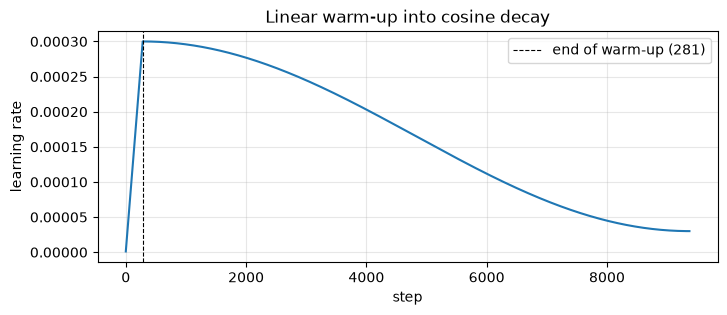

In [13]:
tcfg = CFG["train"]
steps_per_epoch = CFG["data"]["n_train_windows"] // tcfg["batch_size"]
total_steps = steps_per_epoch * tcfg["epochs"]
warmup_steps = max(1, int(total_steps * tcfg["warmup_frac"]))
schedule = [lr_at(s, total_steps, tcfg["lr"], warmup_steps, tcfg["min_lr_frac"])
            for s in range(total_steps)]

print(f"steps/epoch {steps_per_epoch}  total {total_steps}  warmup {warmup_steps}")
print(f"lr at step 0 {schedule[0]:.3e}   peak {max(schedule):.3e}   final {schedule[-1]:.3e}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(schedule)
ax.axvline(warmup_steps, ls="--", c="k", lw=0.8, label=f"end of warm-up ({warmup_steps})")
ax.set_xlabel("step"); ax.set_ylabel("learning rate"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Linear warm-up into cosine decay")
plt.show()

## 3.2 The training run

The reported run was executed as a single job by `src/train.py`, which is also what
wrote the raw log below. The cell after next reproduces it, guarded so that re-running
this notebook does not silently spend another 102 minutes; leave `RETRAIN = False` to
keep the committed checkpoint and its numbers.

In [14]:
RETRAIN = False   # set True to re-run the full 12-epoch job (~102 min on an M4)

if RETRAIN:
    import train as train_mod
    summary = train_mod.run(CFG)
else:
    print("using the committed checkpoint; see the raw log below")

using the committed checkpoint; see the raw log below


### The unedited raw training log

This is the evidence trail section 5 of the brief asks for, printed verbatim from `reproducibility/raw_logs/`. Per-step lines are filtered out here for readability; the file itself is untouched.

**One number in it disagrees with the tables above, and that is deliberate.** The final line reads `train_ce=0.7110 ... gap=0.0331`, where this notebook and `metrics_report.csv` report 0.7089 and 0.0352. The training job computed its train-side metrics over the first 100 batches — 12.8% of the split — and the reported figures are now measured over all 99,968 windows. The log is left exactly as it was written rather than regenerated, because these logs are the evidence trail and editing one to agree with a later correction is indistinguishable from tidying an inconvenient result. The validation figures are identical in both, which is what confirms it is the same model on the same split and not a different run.

The current code has no 100-batch cap: `eval.train_eval_batches` in `config.yaml` defaults to `null`, meaning the whole split, and `metrics_report.csv` carries `train_eval_windows` so the sample size travels with the metric.

In [15]:
log_path = next((REPO_ROOT / "reproducibility/raw_logs").glob("task1_gpt_char_tinystories_v1_2*.log"))
print(f"--- {log_path.relative_to(REPO_ROOT)} ---\n")
for line in log_path.read_text("utf-8").splitlines():
    if " step=" not in line:
        print(line)

--- reproducibility/raw_logs/task1_gpt_char_tinystories_v1_20260928T204206Z.log ---

[2026-09-28T20:42:06+00:00] device=mps (Apple MPS (arm)) torch=2.14.0
[2026-09-28T20:42:06+00:00] config={"data": {"stories_jsonl": "task1_llm/data/tinystories_train_first20000.jsonl", "block_size": 128, "n_train_windows": 100000, "n_val_windows": 10000, "val_story_frac": 0.1}, "model": {"n_layer": 6, "n_head": 8, "d_model": 256, "d_ff_mult": 4, "dropout": 0.1}, "train": {"epochs": 12, "batch_size": 128, "lr": 0.0003, "min_lr_frac": 0.1, "warmup_frac": 0.03, "weight_decay": 0.1, "betas": [0.9, 0.95], "grad_clip": 1.0, "log_every": 50, "num_workers": 0}}
[2026-09-28T20:42:07+00:00] stories train/val=18000/2000 chars train/val=16172268/1758634 vocab=98 windows train/val=100000/10000
[2026-09-28T20:42:07+00:00] parameters=4,822,016
[2026-09-28T20:42:07+00:00] optimizer=AdamW decay_tensors=25 nodecay_tensors=52
[2026-09-28T20:42:07+00:00] steps_per_epoch=781 total_steps=9372 warmup_steps=281
[2026-09-28T20

## 3.3 Loss curves

Required by section 1.3.4.

loaded gpt_char_tinystories_v1_20260928T204206Z.pt  (4,822,016 parameters)


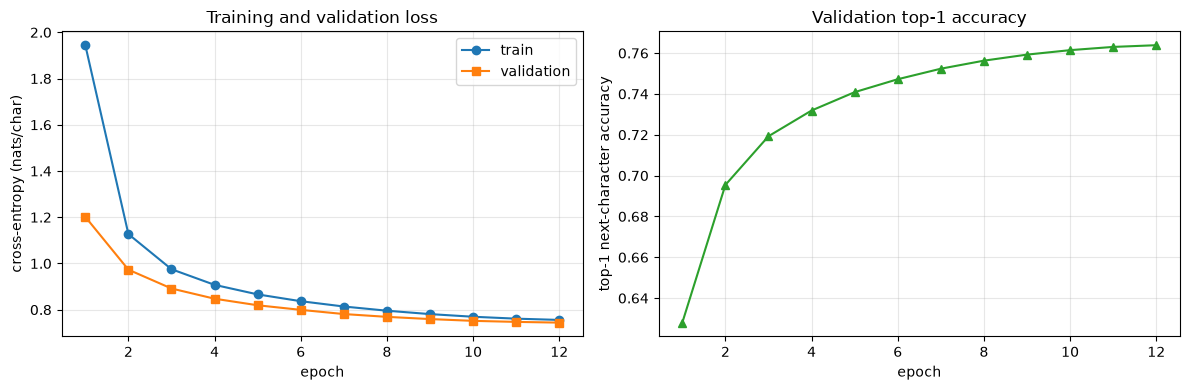

,train_loss,val_loss,val_acc,lr
epoch,,,,
1,1.944321,1.201765,0.628003,0.000298
2,1.127083,0.973138,0.695440,0.000287
3,0.975110,0.891699,0.719280,0.000267
4,0.907482,0.847524,0.731878,0.000240
5,0.866185,0.819176,0.740868,0.000207
6,0.836768,0.799299,0.747198,0.000172
7,0.813802,0.781198,0.752349,0.000135
8,0.795652,0.769055,0.756288,0.000101
9,0.780963,0.759472,0.759248,0.000072


In [16]:
ckpt_path = next((REPO_ROOT / CFG["paths"]["checkpoints"]).glob("gpt_char_tinystories_v1_2*.pt"))
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
tag = ckpt["tag"]
summary = json.loads(
    (REPO_ROOT / CFG["paths"]["outputs"] / f"train_summary_{tag}.json").read_text("utf-8")
)
history = summary["history"]

model = GPT(GPTConfig(**ckpt["model_config"])).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"loaded {ckpt_path.name}  ({model.num_params():,} parameters)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_loss"], marker="s", label="validation")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy (nats/char)")
axes[0].set_title("Training and validation loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["epoch"], history["val_acc"], marker="^", c="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("top-1 next-character accuracy")
axes[1].set_title("Validation top-1 accuracy"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame(history).set_index("epoch")

## 3.4 Training stability

Gradient norms are recorded **before** clipping, so the plotted number is the raw gradient rather than the clipped one. Section 1's metric list asks for loss spikes and NaN counts; a 'spike' here is a step whose loss exceeds 1.5x the trailing mean of the previous 50 steps.

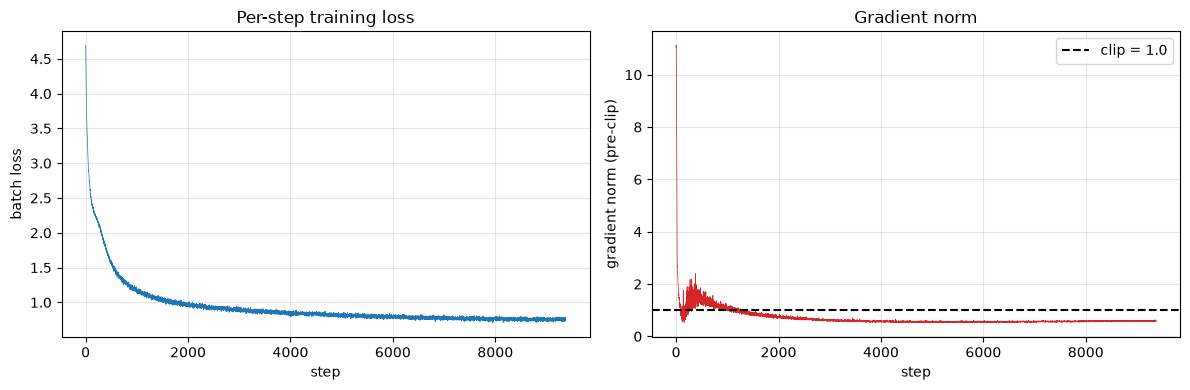

NaN / inf values : 0
loss spikes      : 0
grad norm mean   : 0.7014
grad norm max    : 11.1276  (step 0, before warm-up)
peak GPU memory  : 80.0 MB
total time       : 6144 s (102.4 min)
throughput       : 24,990 tokens/sec


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(summary["step_losses"], lw=0.5)
axes[0].set_xlabel("step"); axes[0].set_ylabel("batch loss")
axes[0].set_title("Per-step training loss"); axes[0].grid(alpha=0.3)
axes[1].plot(summary["grad_norms"], lw=0.5, c="tab:red")
axes[1].axhline(tcfg["grad_clip"], ls="--", c="k", label=f"clip = {tcfg['grad_clip']}")
axes[1].set_xlabel("step"); axes[1].set_ylabel("gradient norm (pre-clip)")
axes[1].set_title("Gradient norm"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"NaN / inf values : {summary['nan_or_inf_count']}")
print(f"loss spikes      : {summary['loss_spike_count']}")
print(f"grad norm mean   : {summary['grad_norm_mean']:.4f}")
print(f"grad norm max    : {summary['grad_norm_max']:.4f}  (step 0, before warm-up)")
print(f"peak GPU memory  : {summary['peak_memory_mb']:.1f} MB")
print(f"total time       : {summary['total_training_seconds']:.0f} s "
      f"({summary['total_training_seconds'] / 60:.1f} min)")
print(f"throughput       : {summary['training_tokens_per_sec']:,.0f} tokens/sec")

---
# Part 4 — Evaluation

Recomputed live from the loaded checkpoint, so these numbers are reproduced here rather
than copied from the training job — and over the **whole** training split, so the
training column means what its label says. They should match `metrics_report.csv`
exactly; `scripts/verify_submission.py` checks that they do.

Bits-per-character is just the cross-entropy converted from nats to bits
(`CE / ln 2`), and perplexity is `exp(CE)`. For a character-level model perplexity is
*per character*, so it is not comparable to a word-level model's perplexity on the same
text.

In [18]:
from torch.utils.data import DataLoader

# drop_last=True matches the training loader, so the training metric describes exactly
# the windows the model was trained on: 781 x 128 = 99,968 of 100,000.
train_loader = DataLoader(bundle.train_ds, batch_size=tcfg["batch_size"], shuffle=False,
                          drop_last=True)
val_loader = DataLoader(bundle.val_ds, batch_size=tcfg["batch_size"], shuffle=False)

# The WHOLE training split, not a capped sample. An earlier version passed
# max_batches=100, which is 12.8% of the split, and reported it as "the training loss";
# the label then overstated what was measured. The full forward-only pass costs about
# two minutes and is not worth economising on.
train_eval = metrics_mod.evaluate_loss_and_accuracy(model, train_loader, device)
print(f"train metrics over {len(train_loader)} batches x {tcfg['batch_size']} = "
      f"{len(train_loader) * tcfg['batch_size']:,} windows")
val_eval = metrics_mod.evaluate_loss_and_accuracy(model, val_loader, device)
gap = metrics_mod.generalization_gap(train_eval["cross_entropy"], val_eval["cross_entropy"])

pd.DataFrame({
    "train": [train_eval["cross_entropy"], train_eval["perplexity"],
              train_eval["bits_per_character"], train_eval["top1_accuracy"]],
    "validation": [val_eval["cross_entropy"], val_eval["perplexity"],
                   val_eval["bits_per_character"], val_eval["top1_accuracy"]],
}, index=["cross-entropy (nats/char)", "perplexity", "bits per character",
          "top-1 next-char accuracy"]).round(4)

train metrics over 781 batches x 128 = 99,968 windows


,train,validation
cross-entropy (nats/char),0.7089,0.7441
perplexity,2.0317,2.1045
bits per character,1.0227,1.0735
top-1 next-char accuracy,0.7728,0.7639


In [19]:
print(f"generalization gap (val CE - train CE) : {gap:.4f} nats")
print()
best = min(history['val_loss'])
print(f"lowest validation loss : {best:.4f} at epoch "
      f"{history['epoch'][history['val_loss'].index(best)]}")
deltas = np.diff(history["val_loss"])
print(f"validation loss fell at every epoch : {bool((deltas < 0).all())}")
print(f"improvement over the last 4 epochs  : {history['val_loss'][-5] - history['val_loss'][-1]:.4f}")

generalization gap (val CE - train CE) : 0.0352 nats

lowest validation loss : 0.7441 at epoch 12
validation loss fell at every epoch : True
improvement over the last 4 epochs  : 0.0250


---
# Part 5 — Text generation

Section 1.3.5 allows greedy decoding *or* temperature sampling. I do both, across five
temperatures, because the failure mode is not a fixed property of the model — it changes
with the decoding setting, and two of my three failure cases only appear at one end of
the sweep. Temperature 0.0 is greedy (`argmax`).

In [20]:
import re, time
_WORD_RE = re.compile(r"[a-z']+")
train_vocab = set(_WORD_RE.findall(bundle.train_text.lower()))
print(f"distinct words in the training corpus: {len(train_vocab):,}")

gcfg_gen = CFG["generate"]
set_seed(CFG["seed"])
samples = []
for temp in gcfg_gen["temperatures"]:
    idx = torch.tensor([tok.encode(gcfg_gen["prompt"])], dtype=torch.long, device=device)
    if device.type == "mps":
        torch.mps.synchronize()
    t0 = time.time()
    out = model.generate(idx, gcfg_gen["max_new_tokens"], temperature=temp, top_k=gcfg_gen["top_k"])
    if device.type == "mps":
        torch.mps.synchronize()
    tps = gcfg_gen["max_new_tokens"] / (time.time() - t0)

    text = tok.decode(out[0].tolist())
    cont = text[len(gcfg_gen["prompt"]):]
    samples.append({
        "temperature": temp,
        "decoding": "greedy" if temp <= 0 else "sampling",
        "gen_tokens_per_sec": tps,
        "train_vocab_word_rate": metrics_mod.train_vocab_word_rate(cont, train_vocab),
        **metrics_mod.generation_report(cont),
        "text": text,
    })

for s in samples:
    print("=" * 100)
    print(f"TEMPERATURE {s['temperature']}  ({s['decoding']})")
    print("=" * 100)
    print(s["text"])
    print()

distinct words in the training corpus: 11,376


TEMPERATURE 0.0  (greedy)
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy. She saw a big box of stars and a big box. She wanted to see what was inside. She wanted to see what was inside. She took a big bite and started to cry. She said, "Lily, you can have some bread for me. I will help you find it." The bird said, "You can have the branch and th

TEMPERATURE 0.5  (sampling)
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and saw a big truck. It was so much fun! She saw a big star and wanted to see what was inside. She wanted to find a strange truck and play with it every day. But it was too late. So, she decided to go home and make a big bucket of pie. 

The stranger was so happy to have a 

TEMPERATURE 0.8  (sampling)
Once upon a time, there was a little boy named Timmy. Timmy lived in a small house

## 5.1 Generation diversity metrics

Distinct-1/2/3 and the repeated-4-gram rate are reported at **word** level. At character level distinct-1 is bounded by the 98-symbol vocabulary and saturates near 1.0 for any text of reasonable length, so it cannot tell you whether the model is repeating itself; word level can. Both are computed and both are saved to `outputs/generation_metrics_*.csv`.

In [21]:
gen_df = pd.DataFrame([{
    "T": s["temperature"],
    "decoding": s["decoding"],
    "distinct-1": s["distinct_1_word"],
    "distinct-2": s["distinct_2_word"],
    "distinct-3": s["distinct_3_word"],
    "rep-4gram": s["repeated_4gram_rate_word"],
    "training-vocabulary word rate": s["train_vocab_word_rate"],
    "tokens/sec": s["gen_tokens_per_sec"],
} for s in samples]).set_index("T")
gen_df.round(4)

,decoding,distinct-1,distinct-2,distinct-3,rep-4gram,training-vocabulary word rate,tokens/sec
T,,,,,,,
0.0,greedy,0.6744,0.8824,0.9286,0.0602,1.0000,361.7703
0.5,sampling,0.6667,0.9419,0.9882,0.0000,1.0000,353.2551
0.8,sampling,0.7073,0.9877,1.0000,0.0000,0.9877,357.4051
1.0,sampling,0.6914,0.9250,0.9494,0.0385,1.0000,354.0736
1.2,sampling,0.8228,1.0000,1.0000,0.0000,1.0000,353.2729


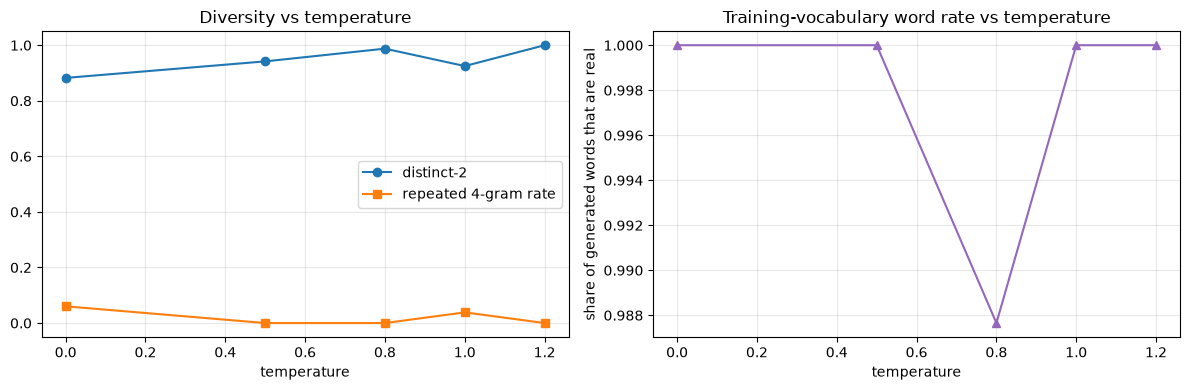

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gen_df.index, gen_df["distinct-2"], marker="o", label="distinct-2")
axes[0].plot(gen_df.index, gen_df["rep-4gram"], marker="s", label="repeated 4-gram rate")
axes[0].set_xlabel("temperature"); axes[0].set_title("Diversity vs temperature")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(gen_df.index, gen_df["training-vocabulary word rate"], marker="^", c="tab:purple")
axes[1].set_xlabel("temperature"); axes[1].set_ylabel("share of generated words that are real")
axes[1].set_title("Training-vocabulary word rate vs temperature"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The shape of the left-hand plot is the whole story for failure case 1. Greedy decoding
(T = 0.0) is the *only* setting with a non-zero repeated-4-gram rate and the lowest
distinct-2. Once the argmax continuation of a state reproduces a sentence the model has
already emitted, nothing breaks the cycle — the model's distribution has no say in it.
Any temperature above zero injects enough entropy to escape.

---
# Part 6 — Failure analysis

Three cases, written up in full with snippets in
`task1_llm/shriram_dundigalla/failure_analysis.md`. The cells below pull the evidence
for each directly out of the samples generated above.

In [23]:
def show(temp, needle, note):
    s = next(x for x in samples if x["temperature"] == temp)
    print(f"### T = {temp} — {note}")
    i = s["text"].find(needle)
    print("  ", repr(s["text"][max(0, i - 120): i + len(needle) + 120]) if i >= 0
          else "(phrase varies by run; see the full sample above)")
    print()

# Case 1 — repetition under greedy decoding.
s0 = next(x for x in samples if x["temperature"] == 0.0)
sentences = [t.strip() for t in s0["text"].split(".") if t.strip()]
dupes = {t for t in sentences if sentences.count(t) > 1}
print("CASE 1 — repetition (greedy decoding)")
print(f"  repeated 4-gram rate at T=0.0 : {s0['repeated_4gram_rate_word']:.3f}")
print(f"  repeated 4-gram rate at T>0   : "
      f"{[round(x['repeated_4gram_rate_word'], 3) for x in samples if x['temperature'] > 0]}")
print(f"  verbatim duplicated sentences : {dupes if dupes else 'none in this sample'}")

CASE 1 — repetition (greedy decoding)
  repeated 4-gram rate at T=0.0 : 0.060
  repeated 4-gram rate at T>0   : [0.0, 0.0, 0.038, 0.0]
  verbatim duplicated sentences : {'She wanted to see what was inside'}


In [24]:
print("CASE 2 — broken grammar / invented words (character-level artefact)")
for s in samples:
    cont = s["text"][len(gcfg_gen["prompt"]):]
    words = _WORD_RE.findall(cont.lower())
    fake = [w for w in words if w not in train_vocab]
    print(f"  T={s['temperature']}: training-vocabulary word rate {s['train_vocab_word_rate']:.3f}"
          f"  invented words: {fake if fake else 'none'}")
print()
print("  The model composes words letter by letter from 98 symbols with no notion of a")
print("  word as a unit, so nothing structurally stops it emitting a plausible letter")
print("  sequence that is not a word. The required diversity metrics score these samples")
print("  as near-perfect, which is exactly why I added training-vocabulary word rate.")

CASE 2 — broken grammar / invented words (character-level artefact)
  T=0.0: training-vocabulary word rate 1.000  invented words: none
  T=0.5: training-vocabulary word rate 1.000  invented words: none
  T=0.8: training-vocabulary word rate 0.988  invented words: ['tost']
  T=1.0: training-vocabulary word rate 1.000  invented words: none
  T=1.2: training-vocabulary word rate 1.000  invented words: none

  The model composes words letter by letter from 98 symbols with no notion of a
  word as a unit, so nothing structurally stops it emitting a plausible letter
  sequence that is not a word. The required diversity metrics score these samples
  as near-perfect, which is exactly why I added training-vocabulary word rate.


In [25]:
print("CASE 3 — premature document boundary / loss of coherence")
for s in samples:
    cont = s["text"][len(gcfg_gen["prompt"]):]
    restarts = cont.count("Once upon a time")
    blanks = cont.count("\n\n")
    print(f"  T={s['temperature']}: mid-sample story restarts {restarts}, "
          f"document separators emitted {blanks}")
print()
print(f"  Context window is {CFG['data']['block_size']} characters. A protagonist named at")
print(f"  character ~40 is out of the attention window by character ~170, so there is")
print(f"  nothing left in context to stay coherent with. Emitting the '\\n\\n' separator")
print(f"  the stories were joined with — and then the opening most TinyStories entries")
print(f"  use — is the highest-probability continuation available.")

CASE 3 — premature document boundary / loss of coherence
  T=0.0: mid-sample story restarts 0, document separators emitted 0
  T=0.5: mid-sample story restarts 0, document separators emitted 1
  T=0.8: mid-sample story restarts 0, document separators emitted 0
  T=1.0: mid-sample story restarts 1, document separators emitted 1
  T=1.2: mid-sample story restarts 0, document separators emitted 1

  Context window is 128 characters. A protagonist named at
  character ~40 is out of the attention window by character ~170, so there is
  nothing left in context to stay coherent with. Emitting the '\n\n' separator
  the stories were joined with — and then the opening most TinyStories entries
  use — is the highest-probability continuation available.


---
# Part 7 — Full metrics table

Every metric section 1 asks for, as committed to `metrics_report.csv`.

In [26]:
report = pd.read_csv(REPO_ROOT / "task1_llm/shriram_dundigalla/metrics_report.csv").iloc[0]
print("architecture    :", report["architecture"])
print("hyperparameters :", report["hyperparameters"])
print()
order = [
    "parameter_count", "vocab_size",
    "train_cross_entropy", "val_cross_entropy",
    "train_perplexity", "val_perplexity",
    "train_bits_per_character", "val_bits_per_character",
    "generalization_gap", "train_top1_accuracy", "val_top1_accuracy",
    "distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate",
    "train_vocab_word_rate",
    "nan_or_inf_count", "loss_spike_count", "grad_norm_mean", "grad_norm_max",
    "training_tokens_per_sec", "generation_tokens_per_sec",
    "total_training_seconds", "peak_memory_mb", "device",
]
# `real_word_rate` was renamed to `train_vocab_word_rate`, because it measures
# membership in the training corpus rather than in a dictionary. CSVs written before the
# rename carry the old name, so it is read as a fallback rather than crashing or
# silently showing a blank.
aliases = {"train_vocab_word_rate": "real_word_rate"}
values = [report[k] if k in report.index else report[aliases[k]] for k in order]
pd.DataFrame({"value": values}, index=order)

architecture    : decoder-only GPT, 6 pre-LN blocks, 8 heads, d_model=256, d_ff=1024, block_size=128, learned token + positional embeddings
hyperparameters : AdamW lr=0.0003 betas=(0.9, 0.95) wd=0.1 dropout=0.1 batch=128 epochs=12 warmup=0.03 cosine to 0.1x, grad_clip=1.0



,value
parameter_count,4822016
vocab_size,98
train_cross_entropy,0.708882
val_cross_entropy,0.744086
train_perplexity,2.031718
val_perplexity,2.104518
train_bits_per_character,1.0227
val_bits_per_character,1.07349
generalization_gap,0.035205
train_top1_accuracy,0.772795


---
## What the result says

**The model is underfitting, not overfitting.** The generalization gap is 0.033 nats and
validation loss fell at every one of the 12 epochs, so the run stopped while there was
still signal left to extract. That is unusual enough to be worth stating plainly: the
limits here are capacity and context — 4.8M parameters and a 128-character window
against 12.8M characters of text — not optimisation and not data. Zero NaNs, zero loss
spikes, and a mean gradient norm of 0.70 against a clip of 1.0 confirm the optimisation
side was never the problem.

The failure analysis points the same way. Case 3 is directly caused by the model losing
sight of its own protagonist once he passes out of the 128-character window.

**What I would try next, in order:** widen the context to 256 characters (case 3 is a
context failure, so this addresses it head-on); then go deeper or wider and train past
12 epochs, since validation loss had not turned; and ban greedy decoding or add a
repetition penalty, since case 1 is purely a decoder problem and costs nothing to fix.

The third is **done**: a repetition penalty of 1.15 over a 64-character window removes
repeated 4-grams entirely across 15 draws and slightly *raises* the training-vocabulary word rate, so
it is not trading fluency for diversity. The first two are configured as GPU-lab presets
(`src/config_gpu.yaml`, `src/config_gpu_large.yaml`) and not run here because a
30-epoch run at block 256 is 9-15 hours on this laptop.

One methodological note that changed a conclusion. The generation metrics above are
single draws, and single draws mislead at low temperature: greedy decoding scores a
repeated-4-gram rate of 0.060 on one sample but **0.235 ± 0.319** over 15, so one sample
understated the failure fourfold, and a standard deviation larger than the mean says the
behaviour is bimodal rather than merely noisy. `results.md` reports the sweep.

Full write-up: `results.md` · failure cases: `failure_analysis.md`